# Proyek Analisis Data: E-Commerce Public Dataset

- **Nama:** Seni Yanti
- **Email:** seniyanti602@gmail.com
- **ID Dicoding:** CDCC206D6X1673


## Menentukan Pertanyaan Bisnis

- Bagaimana tren penjualan bulanan selama periode 2017–2018?
- Kategori produk apa yang memiliki jumlah penjualan dan total revenue tertinggi selama periode 2017–2018?
- Bagaimana distribusi pelanggan berdasarkan wilayah selama periode 2017–2018?
- Siapa pelanggan dengan nilai RFM tertinggi selama periode 2017–2018 berdasarkan Recency, Frequency, dan Monetary?


## Import Semua Packages/Library yang Digunakan

In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import folium
from folium.plugins import HeatMap
import warnings
warnings.filterwarnings('ignore')

## Data Wrangling

### Gathering Data

In [9]:
!ls "/content/drive/MyDrive/Data Dicoding/E-commerce-public-dataset/E-Commerce Public Dataset"

customers_dataset.csv
distribusi_wilayah_2017_2018.png
distribusi_wilayah.png
geolocation_dataset.csv
geospatial_customers_2017_2018.html
geospatial_customers.html
kategori_produk_2017_2018.png
kategori_produk.png
main_data.csv
order_items_dataset.csv
order_payments_dataset.csv
order_reviews_dataset.csv
orders_dataset.csv
product_category_name_translation.csv
products_dataset.csv
rfm_analysis_2017_2018.png
rfm_analysis.png
rfm_clustering.png
rfm_segmentasi_2017_2018.png
rfm_segmentasi.png
rfm_segmentasi_recency_monetary_2017_2018.png
sellers_dataset.csv
tren_bulanan_2017_2018.png
tren_bulanan.png


In [10]:
from google.colab import drive
drive.mount('/content/drive')
folder_path = '/content/drive/MyDrive/Data Dicoding/E-commerce-public-dataset/E-Commerce Public Dataset'
os.chdir(folder_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
customers_df = pd.read_csv('customers_dataset.csv')
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [12]:
orders_df = pd.read_csv('orders_dataset.csv')
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [13]:
order_items_df = pd.read_csv('order_items_dataset.csv')
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [14]:
products_df = pd.read_csv('products_dataset.csv')
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [15]:
sellers_df = pd.read_csv('sellers_dataset.csv')
sellers_df.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [16]:
geolocation_df = pd.read_csv('geolocation_dataset.csv')
geolocation_df.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [17]:
order_payments_df = pd.read_csv('order_payments_dataset.csv')
order_payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [18]:
order_reviews_df = pd.read_csv('order_reviews_dataset.csv')
order_reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [19]:
category_translation_df = pd.read_csv('product_category_name_translation.csv')
category_translation_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


**Insight:**
- Dataset terdiri dari 9 file CSV yang saling berhubungan.
  customers_dataset berisi data pelanggan dengan kolom utama
  customer_id, customer_unique_id, kota, dan state.
- orders_dataset sudah langsung menampilkan status "delivered"
  di 5 baris pertama, artinya mayoritas data memang pesanan
  yang sudah terselesaikan.
- products_dataset menyimpan nama kategori dalam bahasa Portugis
  (seperti perfumaria, esporte_lazer, bebes) sehingga perlu
  digabung dengan product_category_name_translation untuk
  mendapatkan nama kategori dalam bahasa Inggris.
- geolocation_dataset berisi koordinat latitude dan longitude
  per kode pos, terlihat kode pos 1046 muncul dua kali dengan
  koordinat berbeda — ini konfirmasi awal bahwa dataset ini
  punya duplikasi yang perlu dibersihkan.
- order_reviews_dataset banyak sekali nilai NaN di kolom
  review_comment_title dan review_comment_message, artinya
  kebanyakan pelanggan memberikan rating tanpa menulis komentar.
- product_category_name_translation berhasil memuat terjemahan
  kategori dari Portugis ke Inggris, contohnya beleza_saude
  jadi health_beauty dan cama_mesa_banho jadi bed_bath_table.

### Assessing Data

In [20]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [21]:
customers_df.isna().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [22]:
print('Jumlah duplikasi:', customers_df.duplicated().sum())

Jumlah duplikasi: 0


In [23]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [24]:
orders_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [25]:
print('Jumlah duplikasi:', orders_df.duplicated().sum())

Jumlah duplikasi: 0


In [26]:
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [27]:
order_items_df.isna().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [28]:
print('Jumlah duplikasi:', order_items_df.duplicated().sum())

Jumlah duplikasi: 0


In [29]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [30]:
products_df.isna().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [31]:
print('Jumlah duplikasi:', products_df.duplicated().sum())

Jumlah duplikasi: 0


In [32]:
geolocation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [33]:
geolocation_df.isna().sum()

,0
geolocation_zip_code_prefix,0
geolocation_lat,0
geolocation_lng,0
geolocation_city,0
geolocation_state,0


In [34]:
print('Jumlah duplikasi geolocation:', geolocation_df.duplicated().sum())

Jumlah duplikasi geolocation: 261831


**Insight:**
- Beberapa kolom tanggal pada dataset orders_df masih bertipe object, sehingga perlu dikonversi ke datetime agar dapat digunakan untuk analisis berbasis waktu seperti tren dan recency.
- Missing values pada kolom tanggal pengiriman (order_approved_at, order_delivered_carrier_date, dan order_delivered_customer_date) masih dalam batas wajar, karena kemungkinan berasal dari pesanan yang belum selesai diproses atau belum sampai ke pelanggan.
- Pada products_df terdapat missing values pada atribut deskriptif seperti nama, deskripsi, dan jumlah foto produk. Namun, hal ini tidak terlalu mempengaruhi analisis utama karena tidak berkaitan langsung dengan perhitungan jumlah pesanan maupun revenue.
- Dataset geolocation_df memiliki jumlah duplikasi yang sangat besar. Hal ini kemungkinan terjadi karena satu kode pos dapat memiliki beberapa koordinat lokasi yang berbeda, sehingga perlu dilakukan penghapusan duplikasi untuk efisiensi dan konsistensi data.
- Tidak ditemukan duplikasi pada tabel utama seperti orders_df, customers_df, dan order_items_df, sehingga data dapat dianggap cukup bersih dan siap digunakan untuk proses penggabungan (merge) dan analisis lebih lanjut.

Secara keseluruhan, kualitas data sudah cukup baik dan hanya memerlukan beberapa penyesuaian minor sebelum digunakan dalam analisis lebih lanjut.

### Cleaning Data

In [35]:
datetime_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in datetime_cols:
    orders_df[col] = pd.to_datetime(orders_df[col])
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [36]:
orders_df = orders_df[orders_df['order_status'] == 'delivered'].copy()
print('jumlah pesanan delivered:', len(orders_df))

jumlah pesanan delivered: 96478


In [37]:
products_df = products_df.merge(category_translation_df, on='product_category_name', how='left')
products_df['product_category_name_english'].fillna('others', inplace=True)
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


In [38]:
geolocation_df.drop_duplicates(subset='geolocation_zip_code_prefix', inplace=True)
print('geolocation setelah dibersihkan:', len(geolocation_df))

geolocation setelah dibersihkan: 19015


In [39]:
all_df = orders_df.merge(order_items_df, on='order_id', how='left')
all_df = all_df.merge(products_df[['product_id', 'product_category_name_english']], on='product_id', how='left')
all_df = all_df.merge(customers_df, on='customer_id', how='left')
all_df = all_df.merge(
    geolocation_df[['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng']],
    left_on='customer_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
)
all_df['order_year_month'] = all_df['order_purchase_timestamp'].dt.to_period('M').astype(str)
all_df['revenue'] = all_df['price'] + all_df['freight_value']
print(all_df.shape)
all_df.head()

(110197, 24)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_category_name_english,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,order_year_month,revenue
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,housewares,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,3149.0,-23.574809,-46.587471,2017-10,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,perfumery,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,47813.0,-12.169860,-44.988369,2018-07,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,auto,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,75265.0,-16.746337,-48.514624,2018-08,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,pet_shop,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,59296.0,-5.767733,-35.275467,2017-11,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,...,stationery,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,9195.0,-23.675037,-46.524784,2018-02,28.62


**Insight:**
- Setelah dilakukan filtering hanya pada pesanan dengan status "delivered", dataset menjadi lebih representatif untuk analisis karena hanya mencakup transaksi yang benar-benar selesai. Hal ini penting untuk menghindari bias dari pesanan yang dibatalkan atau masih dalam proses.
- Proses penggabungan (merge) beberapa tabel berhasil menghasilkan satu dataframe utama (all_df) yang mengintegrasikan informasi pelanggan, produk, transaksi, dan lokasi. Data ini sudah cukup lengkap untuk mendukung analisis EDA dan visualisasi lebih lanjut.
- Variabel revenue dihitung sebagai penjumlahan antara price dan freight_value, sehingga mencerminkan total nilai transaksi yang dibayarkan pelanggan, termasuk biaya pengiriman. Pendefinisian ini penting agar analisis revenue lebih realistis dari sisi bisnis.
- Setelah dilakukan penggabungan dengan data geolocation, ditemukan beberapa baris dengan informasi lokasi yang tidak lengkap. Hal ini kemungkinan disebabkan oleh ketidaksesuaian kode pos antara dataset pelanggan dan geolokasi, namun jumlahnya relatif kecil sehingga tidak berdampak signifikan terhadap keseluruhan analisis.

Secara keseluruhan, data telah melalui proses pembersihan dan integrasi dengan baik sehingga siap digunakan untuk analisis eksploratif dan menjawab pertanyaan bisnis yang telah ditentukan.

## Exploratory Data Analysis (EDA)

In [40]:
all_df['order_purchase_timestamp'] = pd.to_datetime(all_df['order_purchase_timestamp'])

filtered_df = all_df[
    (all_df['order_purchase_timestamp'] >= '2017-01-01') &
    (all_df['order_purchase_timestamp'] <= '2018-12-31')
].copy()

filtered_df['order_year_month'] = filtered_df['order_purchase_timestamp'].dt.to_period('M').astype(str)

print("Periode analisis:", filtered_df['order_purchase_timestamp'].min(), "sampai", filtered_df['order_purchase_timestamp'].max())
print("Jumlah baris data:", filtered_df.shape[0])

Periode analisis: 2017-01-05 11:56:06 sampai 2018-08-29 15:00:37
Jumlah baris data: 109880


### Explore Tren Pesanan Bulanan

In [41]:
monthly_df = filtered_df.groupby('order_year_month').agg(
    order_count=('order_id', 'nunique'),
    total_revenue=('revenue', 'sum')
).reset_index()

monthly_df.describe()

,order_count,total_revenue
count,20.00000,2.000000e+01
mean,4810.55000,7.686560e+05
std,2016.19155,3.206784e+05
min,750.00000,1.274824e+05
25%,3443.25000,5.472369e+05
50%,4995.50000,7.970977e+05
75%,6603.50000,1.040327e+06
max,7289.00000,1.153364e+06


In [42]:
print('bulan paling ramai:', monthly_df.loc[monthly_df['order_count'].idxmax(), 'order_year_month'])
print('bulan paling sepi:', monthly_df.loc[monthly_df['order_count'].idxmin(), 'order_year_month'])

bulan paling ramai: 2017-11
bulan paling sepi: 2017-01


### Explore Kategori Produk

In [43]:
category_agg = filtered_df.groupby('product_category_name_english').agg(
    total_orders=('order_id', 'count'),
    total_revenue=('revenue', 'sum')
).reset_index().sort_values('total_orders', ascending=False)

category_agg.head(10)

,product_category_name_english,total_orders,total_revenue
7,bed_bath_table,10945,1224602.68
43,health_beauty,9422,1407759.78
66,sports_leisure,8414,1115766.15
39,furniture_decor,8095,873430.57
15,computers_accessories,7632,1031861.93
49,housewares,6783,756849.71
71,watches_gifts,5855,1261539.41
69,telephony,4422,378868.37
42,garden_tools,4263,565680.49
5,auto,4132,668103.48


In [44]:
print('kategori dengan jumlah pesanan tertinggi:', category_agg.loc[category_agg['total_orders'].idxmax(), 'product_category_name_english'])
print('kategori dengan total revenue tertinggi:', category_agg.loc[category_agg['total_revenue'].idxmax(), 'product_category_name_english'])

kategori dengan jumlah pesanan tertinggi: bed_bath_table
kategori dengan total revenue tertinggi: health_beauty


### Explore Distribusi Pelanggan

In [45]:
bystate_df = filtered_df.groupby('customer_state').customer_unique_id.nunique().sort_values(ascending=False).reset_index()
bystate_df.columns = ['customer_state', 'customer_count']

bystate_df.head(10)

,customer_state,customer_count
0,SP,39065
1,RJ,11879
2,MG,10969
3,RS,5151
4,PR,4750
5,SC,3441
6,BA,3155
7,DF,2013
8,ES,1925
9,GO,1889


In [46]:
bycity_df = filtered_df.groupby('customer_city').customer_unique_id.nunique().sort_values(ascending=False).reset_index()
bycity_df.columns = ['customer_city', 'customer_count']

bycity_df.head(10)

,customer_city,customer_count
0,sao paulo,14500
1,rio de janeiro,6336
2,belo horizonte,2597
3,brasilia,2007
4,curitiba,1429
5,campinas,1357
6,porto alegre,1290
7,salvador,1154
8,guarulhos,1110
9,sao bernardo do campo,878


In [47]:
print('state dengan pelanggan terbanyak:', bystate_df.loc[bystate_df['customer_count'].idxmax(), 'customer_state'])
print('kota dengan pelanggan terbanyak:', bycity_df.loc[bycity_df['customer_count'].idxmax(), 'customer_city'])

state dengan pelanggan terbanyak: SP
kota dengan pelanggan terbanyak: sao paulo


## Insight

- Berdasarkan analisis data transaksi periode 2017–2018, jumlah pesanan bulanan menunjukkan pola fluktuatif dengan rata-rata sekitar 4.810 pesanan per bulan dan standar deviasi yang cukup tinggi (~2.016). Hal ini mengindikasikan adanya variasi permintaan yang signifikan antar bulan, sehingga pola penjualan tidak bersifat stabil sepanjang waktu.

- Puncak jumlah pesanan terjadi pada November 2017, sedangkan periode dengan aktivitas terendah terjadi pada Januari 2017. Pola ini menunjukkan adanya indikasi seasonality, di mana peningkatan transaksi kemungkinan dipengaruhi oleh momentum promosi besar seperti akhir tahun atau event khusus (misalnya Black Friday), sedangkan awal tahun cenderung mengalami penurunan aktivitas transaksi.

- Dari sisi kategori produk, kategori **bed_bath_table** memiliki jumlah pesanan tertinggi, sedangkan kategori **health_beauty** menghasilkan total revenue terbesar selama periode 2017–2018. Hal ini menunjukkan bahwa kategori dengan volume transaksi tinggi tidak selalu menjadi penyumbang revenue terbesar, sehingga terdapat perbedaan karakteristik nilai transaksi antar kategori.

- Distribusi pelanggan menunjukkan konsentrasi yang sangat tinggi di state **SP (Sao Paulo)**, yang secara signifikan mendominasi jumlah pelanggan dibandingkan wilayah lain seperti RJ dan MG. Hal ini mengindikasikan bahwa pusat aktivitas e-commerce berada di wilayah tersebut dan berpotensi menjadi pasar utama dalam strategi bisnis.

- Pada tingkat kota, **Sao Paulo** menjadi kota dengan jumlah pelanggan tertinggi, diikuti oleh Rio de Janeiro dan Belo Horizonte. Pola ini menunjukkan bahwa aktivitas transaksi e-commerce cenderung terkonsentrasi pada kota-kota besar (urban area), yang umumnya memiliki tingkat adopsi teknologi dan daya beli yang lebih tinggi.

Secara keseluruhan, selama periode 2017–2018 terdapat pola musiman dalam transaksi, dominasi kategori tertentu dalam volume dan revenue, serta konsentrasi pelanggan di wilayah urban. Insight ini dapat digunakan sebagai dasar untuk pengambilan keputusan bisnis, seperti penentuan strategi promosi musiman, fokus pada kategori produk unggulan, serta optimalisasi pemasaran di wilayah dengan konsentrasi pelanggan tinggi.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren penjualan bulanan selama periode 2017–2018?


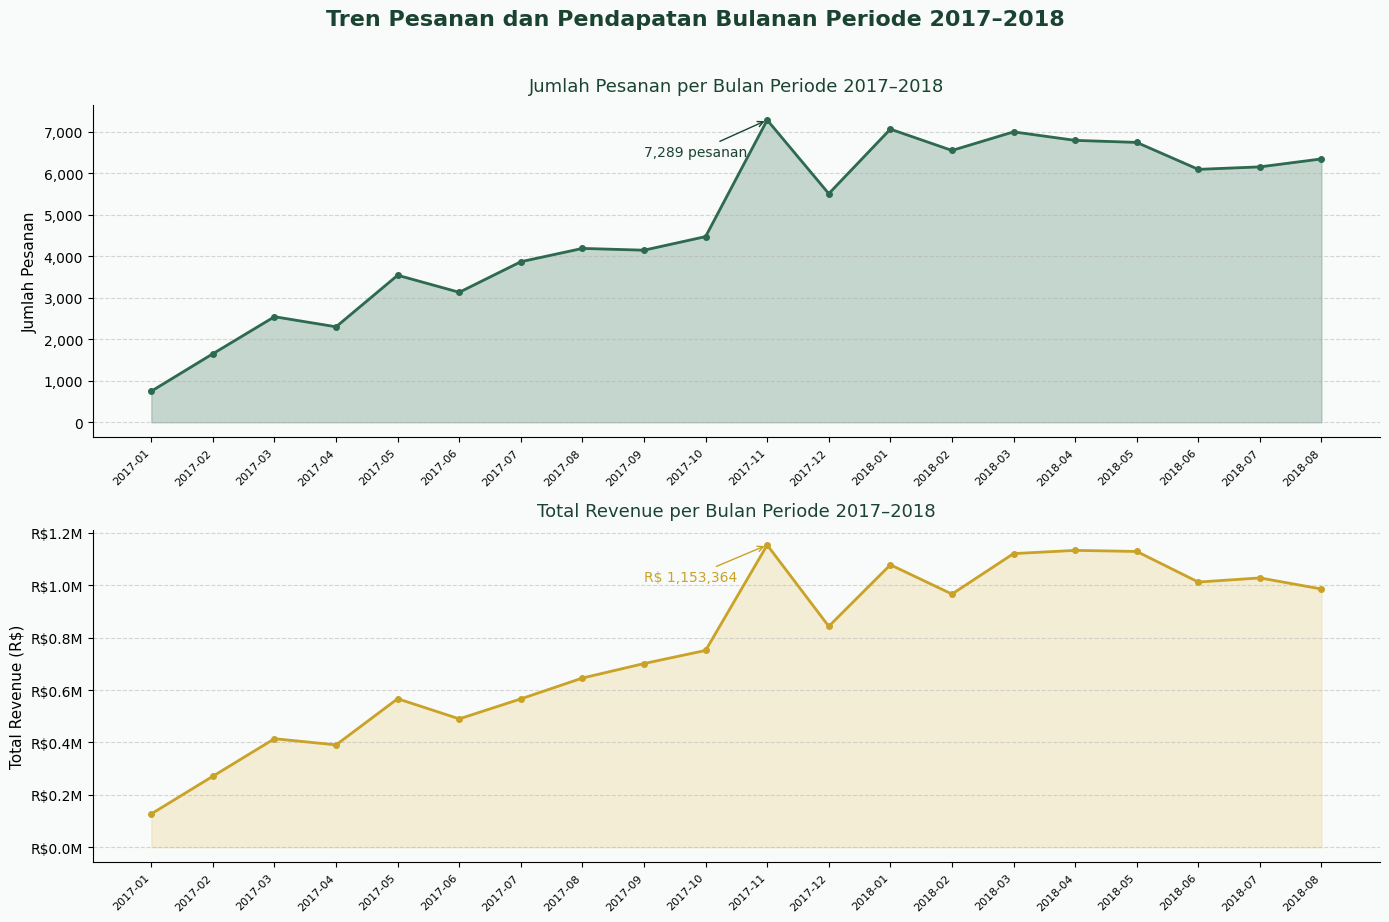

In [48]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.patch.set_facecolor('#F8FBF9')

x = range(len(monthly_df))

# plot jumlah pesanan
axes[0].set_facecolor('#F8FBF9')
axes[0].fill_between(x, monthly_df['order_count'], alpha=0.25, color='#2D6A4F')
axes[0].plot(x, monthly_df['order_count'], color='#2D6A4F', linewidth=2, marker='o', markersize=4)

peak = monthly_df['order_count'].idxmax()
peak_pos = monthly_df.index.get_loc(peak)

axes[0].annotate(
    f"{monthly_df.loc[peak,'order_count']:,} pesanan",
    xy=(peak_pos, monthly_df.loc[peak,'order_count']),
    xytext=(max(0, peak_pos-2), monthly_df.loc[peak,'order_count'] * 0.88),
    arrowprops=dict(arrowstyle='->', color='#1B4332'),
    fontsize=10, color='#1B4332'
)

axes[0].set_xticks(list(x))
axes[0].set_xticklabels(monthly_df['order_year_month'], rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Jumlah Pesanan', fontsize=11)
axes[0].set_title('Jumlah Pesanan per Bulan Periode 2017–2018', fontsize=13, color='#1B4332', pad=10)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# plot total revenue
axes[1].set_facecolor('#F8FBF9')
axes[1].fill_between(x, monthly_df['total_revenue'], alpha=0.25, color='#E9C46A')
axes[1].plot(x, monthly_df['total_revenue'], color='#C9A227', linewidth=2, marker='o', markersize=4)

peak_rev = monthly_df['total_revenue'].idxmax()
peak_rev_pos = monthly_df.index.get_loc(peak_rev)

axes[1].annotate(
    f"R$ {monthly_df.loc[peak_rev,'total_revenue']:,.0f}",
    xy=(peak_rev_pos, monthly_df.loc[peak_rev,'total_revenue']),
    xytext=(max(0, peak_rev_pos-2), monthly_df.loc[peak_rev,'total_revenue'] * 0.88),
    arrowprops=dict(arrowstyle='->', color='#C9A227'),
    fontsize=10, color='#C9A227'
)

axes[1].set_xticks(list(x))
axes[1].set_xticklabels(monthly_df['order_year_month'], rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Total Revenue (R$)', fontsize=11)
axes[1].set_title('Total Revenue per Bulan Periode 2017–2018', fontsize=13, color='#1B4332', pad=10)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Tren Pesanan dan Pendapatan Bulanan Periode 2017–2018', fontsize=16, fontweight='bold', color='#1B4332', y=1.02)
plt.tight_layout()
plt.savefig('tren_bulanan_2017_2018.png', dpi=150, bbox_inches='tight')
plt.show()

### Pertanyaan 2: Kategori produk apa yang memiliki jumlah penjualan dan total revenue tertinggi selama periode 2017–2018?


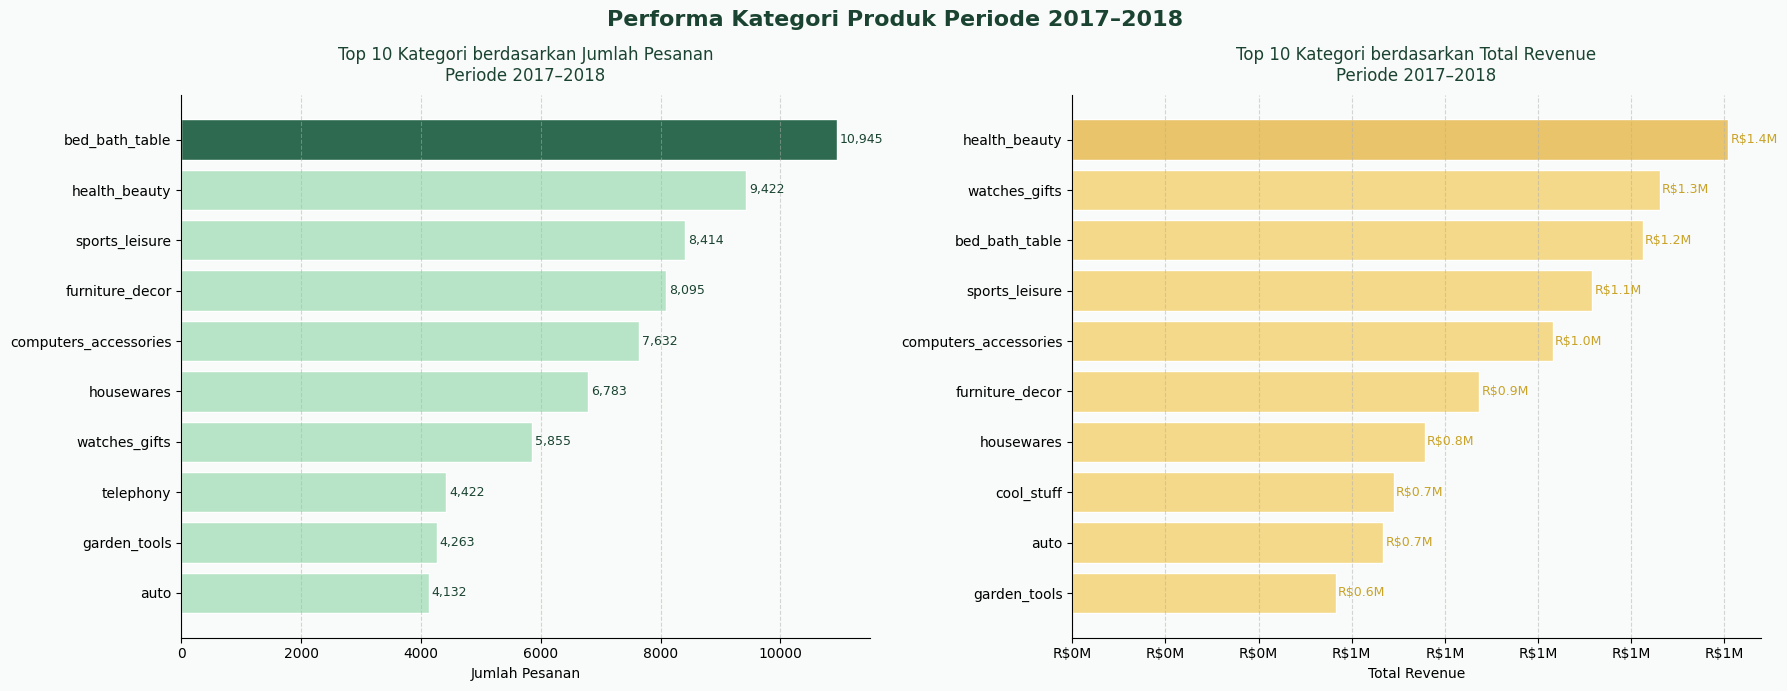

In [49]:
top10_orders = category_agg.sort_values('total_orders', ascending=False).head(10)
top10_revenue = category_agg.sort_values('total_revenue', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#F8FBF9')

# bar kiri - jumlah pesanan
colors_l = ['#2D6A4F' if i == 0 else '#B7E4C7' for i in range(len(top10_orders))]
axes[0].set_facecolor('#F8FBF9')
bars1 = axes[0].barh(
    top10_orders['product_category_name_english'][::-1],
    top10_orders['total_orders'][::-1],
    color=colors_l[::-1],
    edgecolor='white'
)

for bar in bars1:
    w = bar.get_width()
    axes[0].text(
        w + 50,
        bar.get_y() + bar.get_height()/2,
        f'{int(w):,}',
        va='center',
        ha='left',
        fontsize=9,
        color='#1B4332'
    )

axes[0].set_title(
    'Top 10 Kategori berdasarkan Jumlah Pesanan\nPeriode 2017–2018',
    fontsize=12,
    color='#1B4332',
    pad=10
)
axes[0].set_xlabel('Jumlah Pesanan')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].grid(axis='x', linestyle='--', alpha=0.5)

# bar kanan - revenue
colors_r = ['#E9C46A' if i == 0 else '#F4D98A' for i in range(len(top10_revenue))]
axes[1].set_facecolor('#F8FBF9')
bars2 = axes[1].barh(
    top10_revenue['product_category_name_english'][::-1],
    top10_revenue['total_revenue'][::-1],
    color=colors_r[::-1],
    edgecolor='white'
)

for bar in bars2:
    w = bar.get_width()
    axes[1].text(
        w + 5000,
        bar.get_y() + bar.get_height()/2,
        f'R${w/1e6:.1f}M',
        va='center',
        ha='left',
        fontsize=9,
        color='#C9A227'
    )

axes[1].set_title(
    'Top 10 Kategori berdasarkan Total Revenue\nPeriode 2017–2018',
    fontsize=12,
    color='#1B4332',
    pad=10
)
axes[1].set_xlabel('Total Revenue')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.0f}M'))
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

plt.suptitle(
    'Performa Kategori Produk Periode 2017–2018',
    fontsize=16,
    fontweight='bold',
    color='#1B4332'
)
plt.tight_layout()
plt.savefig('kategori_produk_2017_2018.png', dpi=150, bbox_inches='tight')
plt.show()

### Pertanyaan 3:  Bagaimana distribusi pelanggan berdasarkan wilayah selama periode 2017–2018?


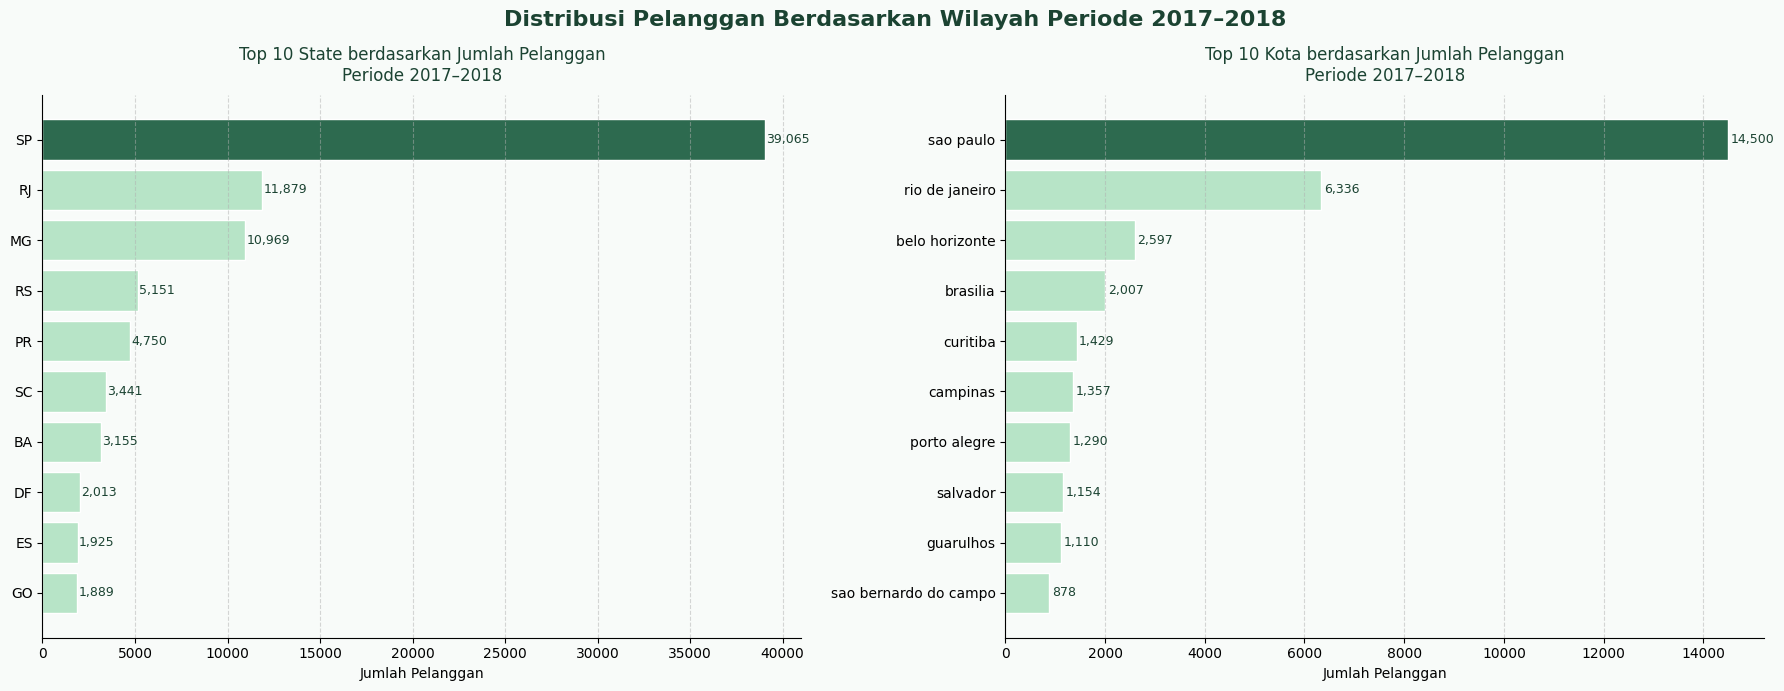

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#F8FBF9')

top10_state = bystate_df.head(10)
colors_s = ['#2D6A4F' if i == 0 else '#B7E4C7' for i in range(len(top10_state))]
axes[0].set_facecolor('#F8FBF9')
bars = axes[0].barh(
    top10_state['customer_state'][::-1],
    top10_state['customer_count'][::-1],
    color=colors_s[::-1],
    edgecolor='white'
)

for bar in bars:
    w = bar.get_width()
    axes[0].text(
        w + 50,
        bar.get_y() + bar.get_height()/2,
        f'{int(w):,}',
        va='center',
        ha='left',
        fontsize=9,
        color='#1B4332'
    )

axes[0].set_title(
    'Top 10 State berdasarkan Jumlah Pelanggan\nPeriode 2017–2018',
    fontsize=12,
    color='#1B4332',
    pad=10
)
axes[0].set_xlabel('Jumlah Pelanggan')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].grid(axis='x', linestyle='--', alpha=0.5)

top10_city = bycity_df.head(10)
colors_c = ['#2D6A4F' if i == 0 else '#B7E4C7' for i in range(len(top10_city))]
axes[1].set_facecolor('#F8FBF9')
bars2 = axes[1].barh(
    top10_city['customer_city'][::-1],
    top10_city['customer_count'][::-1],
    color=colors_c[::-1],
    edgecolor='white'
)

for bar in bars2:
    w = bar.get_width()
    axes[1].text(
        w + 50,
        bar.get_y() + bar.get_height()/2,
        f'{int(w):,}',
        va='center',
        ha='left',
        fontsize=9,
        color='#1B4332'
    )

axes[1].set_title(
    'Top 10 Kota berdasarkan Jumlah Pelanggan\nPeriode 2017–2018',
    fontsize=12,
    color='#1B4332',
    pad=10
)
axes[1].set_xlabel('Jumlah Pelanggan')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

plt.suptitle(
    'Distribusi Pelanggan Berdasarkan Wilayah Periode 2017–2018',
    fontsize=16,
    fontweight='bold',
    color='#1B4332'
)
plt.tight_layout()
plt.savefig('distribusi_wilayah_2017_2018.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:**
- Selama periode 2017–2018, tren jumlah pesanan dan total revenue menunjukkan pola yang meningkat secara bertahap, dengan hubungan yang konsisten antara keduanya. Hal ini mengindikasikan bahwa pertumbuhan revenue lebih banyak didorong oleh peningkatan volume transaksi dibandingkan kenaikan nilai per transaksi.
- Puncak aktivitas transaksi terjadi pada November 2017, yang secara jelas mencerminkan adanya efek musiman (seasonality), kemungkinan besar dipengaruhi oleh event promosi besar seperti Black Friday. Hal ini menunjukkan bahwa strategi promosi pada periode tertentu memiliki dampak signifikan terhadap peningkatan performa bisnis.
- Setelah periode puncak, tren penjualan tetap berada pada level yang relatif tinggi meskipun mengalami fluktuasi. Ini mengindikasikan bahwa bisnis memiliki baseline demand yang stabil, sehingga tidak sepenuhnya bergantung pada event musiman.
- Dari sisi kategori produk, terdapat perbedaan karakteristik antara kategori dengan jumlah pesanan tinggi dan kategori dengan revenue tinggi.
Kategori seperti bed_bath_table mendominasi dari sisi volume transaksi (high-frequency).
- Sementara kategori seperti health_beauty dan watches_gifts menghasilkan revenue lebih tinggi, yang mengindikasikan average order value (AOV) yang lebih besar.
Pola ini menunjukkan adanya segmentasi produk menjadi:
High-volume products dimana fokus pada frekuensi transaksi,
High-value products dimana fokus pada nilai transaksi. Sehingga strategi bisnis dapat dibedakan antara peningkatan volume dan peningkatan nilai transaksi.
- Distribusi pelanggan menunjukkan konsentrasi yang sangat tinggi pada wilayah SP (Sao Paulo), yang secara signifikan mendominasi dibandingkan state lainnya seperti RJ dan MG. Hal ini menunjukkan bahwa pasar utama e-commerce terpusat di wilayah dengan tingkat urbanisasi tinggi.
Pada level kota, Sao Paulo memiliki jumlah pelanggan yang jauh lebih besar dibandingkan kota lainnya, diikuti oleh Rio de Janeiro dan Belo Horizonte. Ini mengindikasikan bahwa aktivitas transaksi e-commerce cenderung terfokus pada kota-kota besar (urban market concentration).

Secara keseluruhan, data menunjukkan bahwa performa bisnis e-commerce selama periode 2017–2018 dipengaruhi oleh kombinasi antara:

a. faktor musiman (event-driven demand),

b. dominasi wilayah tertentu (market concentration),

c. serta perbedaan karakteristik produk (volume vs value).

Hal ini membuka peluang strategi seperti:

1) optimalisasi promosi di periode peak season

2) ekspansi pasar di luar wilayah dominan

3) serta diferensiasi strategi pemasaran berdasarkan kategori produk

## Analisis Lanjutan (Opsional)

###RFM ANALYSIS
###Pertanyaan 4: Siapa pelanggan dengan nilai RFM tertinggi selama periode 2017–2018 berdasarkan Recency, Frequency, dan Monetary?

RFM Analysis digunakan untuk mengelompokkan pelanggan berdasarkan tiga hal:
- Recency (seberapa baru mereka belanja)
- Frequency (seberapa sering mereka belanja)
- Monetary (seberapa total belanjanya)

Tujuannya supaya bisa tau pelanggan mana yang paling berharga dan mana yang perlu diperhatikan.

In [51]:
filtered_df['order_purchase_timestamp'] = pd.to_datetime(filtered_df['order_purchase_timestamp'])
snapshot_date = filtered_df['order_purchase_timestamp'].max() + pd.Timedelta(days=30)
rfm_df = filtered_df.groupby('customer_unique_id').agg(
    recency=('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('revenue', 'sum')
).reset_index()
rfm_df.head()

,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,141,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,144,1,27.19
2,0000f46a3911fa3c0805444483337064,566,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,350,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,317,1,196.89


In [52]:
rfm_df.describe()

,recency,frequency,monetary
count,93104.000000,93104.000000,93104.000000
mean,265.702924,1.033371,165.117718
std,150.942219,0.209012,226.361168
min,30.000000,1.000000,9.590000
25%,143.000000,1.000000,63.007500
50%,247.000000,1.000000,107.780000
75%,374.000000,1.000000,182.425000
max,631.000000,15.000000,13664.080000


In [53]:
rfm_df['r_score'] = pd.qcut(rfm_df['recency'], q=5, labels=[5, 4, 3, 2, 1], duplicates='drop')
rfm_df['f_score'] = pd.qcut(rfm_df['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5], duplicates='drop')
rfm_df['m_score'] = pd.qcut(rfm_df['monetary'], q=5, labels=[1, 2, 3, 4, 5], duplicates='drop')

rfm_df['rfm_score'] = rfm_df[['r_score', 'f_score', 'm_score']].astype(int).sum(axis=1)

rfm_df.describe()

,recency,frequency,monetary,rfm_score
count,93104.000000,93104.000000,93104.000000,93104.000000
mean,265.702924,1.033371,165.117718,9.006401
std,150.942219,0.209012,226.361168,2.499709
min,30.000000,1.000000,9.590000,3.000000
25%,143.000000,1.000000,63.007500,7.000000
50%,247.000000,1.000000,107.780000,9.000000
75%,374.000000,1.000000,182.425000,11.000000
max,631.000000,15.000000,13664.080000,15.000000


In [54]:
def segment_customer(score):
    if score >= 13:
        return 'Champions'
    elif score >= 10:
        return 'Loyal Customers'
    elif score >= 7:
        return 'Potential Loyalists'
    elif score >= 4:
        return 'At Risk'
    else:
        return 'Lost'

rfm_df['segment'] = rfm_df['rfm_score'].apply(segment_customer)

rfm_df['segment'].value_counts()

,count
segment,
Potential Loyalists,38233
Loyal Customers,31454
At Risk,14597
Champions,8033
Lost,787


In [55]:
top5_recency = rfm_df.sort_values('recency', ascending=True).head(5)
top5_frequency = rfm_df.sort_values('frequency', ascending=False).head(5)
top5_monetary = rfm_df.sort_values('monetary', ascending=False).head(5)

print("Top 5 Customer berdasarkan Recency")
display(top5_recency)

print("Top 5 Customer berdasarkan Frequency")
display(top5_frequency)

print("Top 5 Customer berdasarkan Monetary")
display(top5_monetary)

Top 5 Customer berdasarkan Recency


,customer_unique_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,segment
13395,24ac2b4327e25baf39f2119e4228976a,30,1,93.75,5,1,3,9,Potential Loyalists
60876,a712a430955027da5bc257a10073a390,30,1,161.97,5,4,4,13,Champions
64045,afbcfd0b9c5233e7ccc73428526fbb52,30,1,497.25,5,4,5,14,Champions
31279,55cfdb1ec3c5bf60d9ccc0d5f276f8a9,30,1,260.50,5,2,5,12,Loyal Customers
59591,a3bf67d0b92528d2fe5c379dd905bf66,30,1,128.99,5,4,3,12,Loyal Customers


Top 5 Customer berdasarkan Frequency


,customer_unique_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,segment
51290,8d50f5eadf50201ccdcedfb9e2ac8455,38,15,879.27,5,5,5,15,Champions
22711,3e43e6105506432c953e165fb2acf44c,212,9,1172.67,3,5,5,13,Champions
10035,1b6c7548a2a1f9037c1fd3ddfed95f33,226,7,959.01,3,5,5,13,Champions
36602,6469f99c1f9dfae7733b25662e7f1782,92,7,758.83,5,5,5,15,Champions
73727,ca77025e7201e3b30c44b472ff346268,119,7,1122.72,5,5,5,15,Champions


Top 5 Customer berdasarkan Monetary


,customer_unique_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,segment
3716,0a0a92112bd4c708ca5fde585afaa872,363,1,13664.08,2,1,5,8,Potential Loyalists
79420,da122df9eeddfedc1dc1f5349a1a690c,544,2,7571.63,1,5,5,11,Loyal Customers
43051,763c8b1c9c68a0229c42c9fc6f662b93,75,1,7274.88,5,3,5,13,Champions
80246,dc4802a71eae9be1dd28f5d788ceb526,592,1,6929.31,1,5,5,11,Loyal Customers
25360,459bef486812aa25204be022145caa62,64,1,6922.21,5,2,5,12,Loyal Customers


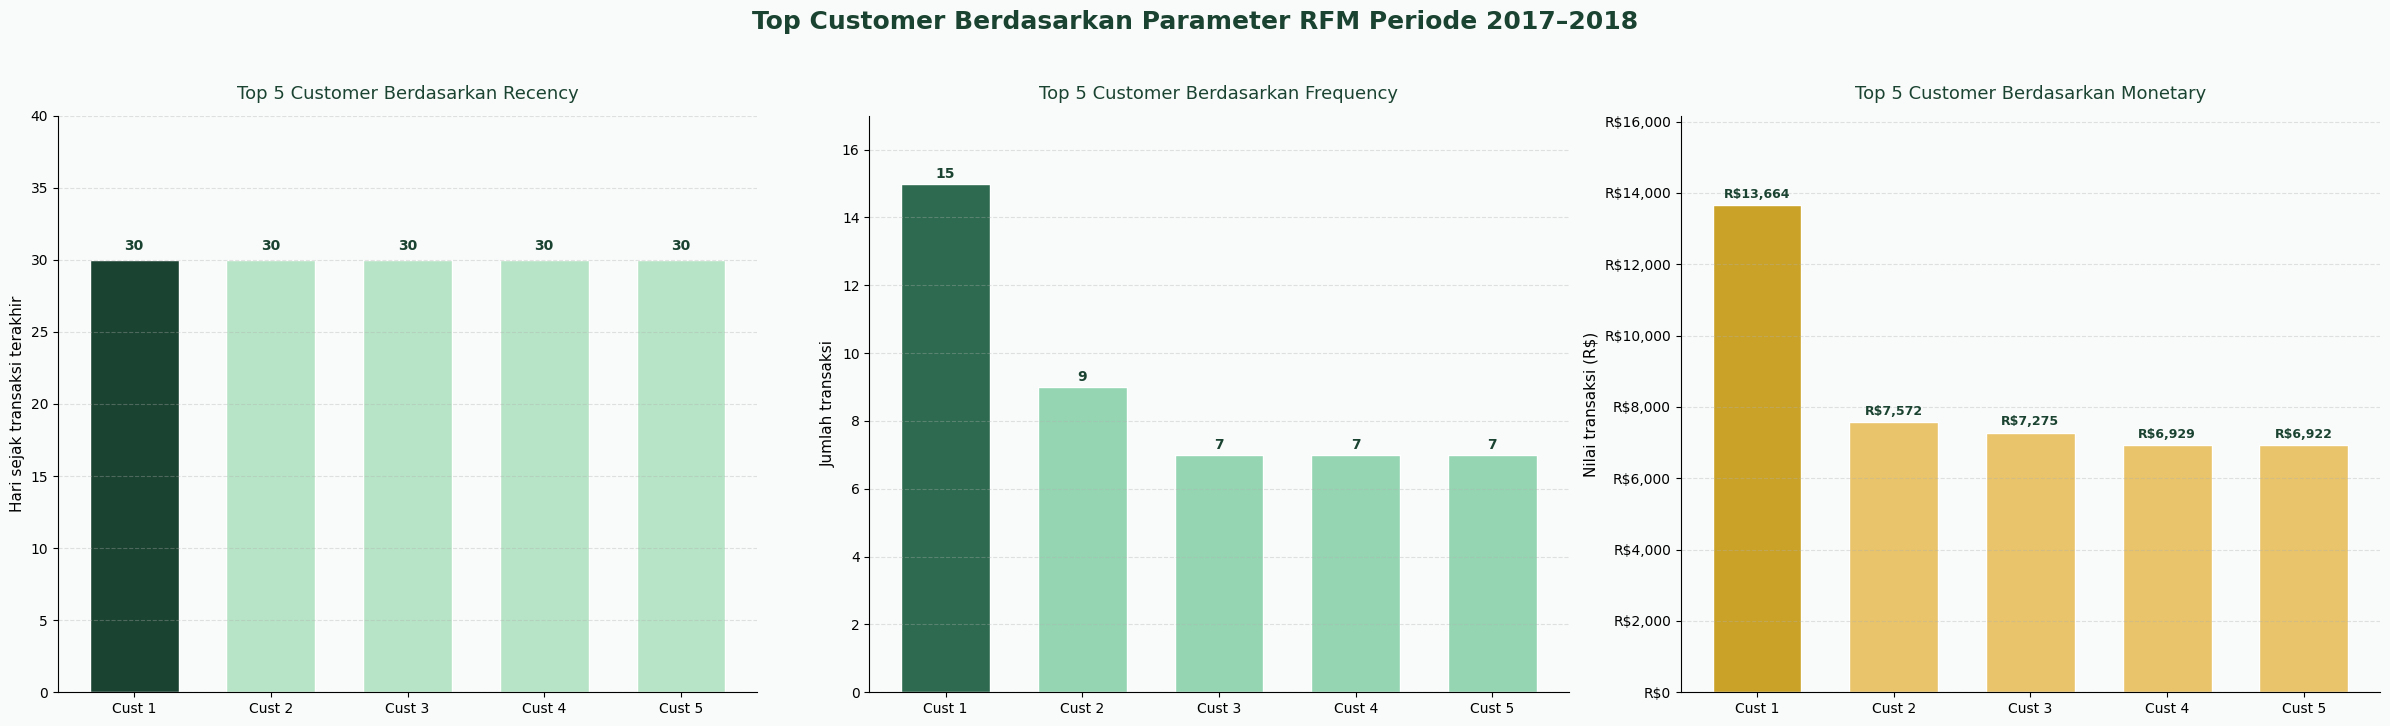

In [56]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(24, 7))
fig.patch.set_facecolor('#F8FBF9')
top5_recency = rfm_df.sort_values('recency', ascending=True).head(5).reset_index(drop=True)

recency_colors = ['#1B4332'] + ['#B7E4C7'] * 4
ax[0].set_facecolor('#F8FBF9')
bars0 = ax[0].bar(
    range(len(top5_recency)),
    top5_recency['recency'],
    color=recency_colors,
    edgecolor='white',
    width=0.65
)

ax[0].set_xticks(range(len(top5_recency)))
ax[0].set_xticklabels([f'Cust {i+1}' for i in range(len(top5_recency))], fontsize=10)
ax[0].set_title(
    'Top 5 Customer Berdasarkan Recency',
    fontsize=13,
    color='#1B4332',
    pad=12
)
ax[0].set_ylabel('Hari sejak transaksi terakhir', fontsize=11)
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].grid(axis='y', linestyle='--', alpha=0.35)
ax[0].set_ylim(0, top5_recency['recency'].max() + 10)

for bar in bars0:
    ax[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{int(bar.get_height())}',
        ha='center',
        va='bottom',
        fontsize=10,
        color='#1B4332',
        fontweight='bold'
    )

top5_freq = rfm_df.sort_values('frequency', ascending=False).head(5).reset_index(drop=True)

freq_colors = ['#2D6A4F'] + ['#95D5B2'] * 4
ax[1].set_facecolor('#F8FBF9')
bars1 = ax[1].bar(
    range(len(top5_freq)),
    top5_freq['frequency'],
    color=freq_colors,
    edgecolor='white',
    width=0.65
)

ax[1].set_xticks(range(len(top5_freq)))
ax[1].set_xticklabels([f'Cust {i+1}' for i in range(len(top5_freq))], fontsize=10)
ax[1].set_title(
    'Top 5 Customer Berdasarkan Frequency',
    fontsize=13,
    color='#1B4332',
    pad=12
)
ax[1].set_ylabel('Jumlah transaksi', fontsize=11)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].grid(axis='y', linestyle='--', alpha=0.35)
ax[1].set_ylim(0, top5_freq['frequency'].max() + 2)

for bar in bars1:
    ax[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.08,
        f'{int(bar.get_height())}',
        ha='center',
        va='bottom',
        fontsize=10,
        color='#1B4332',
        fontweight='bold'
    )

top5_monetary = rfm_df.sort_values('monetary', ascending=False).head(5).reset_index(drop=True)

monetary_colors = ['#C9A227'] + ['#E9C46A'] * 4
ax[2].set_facecolor('#F8FBF9')
bars2 = ax[2].bar(
    range(len(top5_monetary)),
    top5_monetary['monetary'],
    color=monetary_colors,
    edgecolor='white',
    width=0.65
)

ax[2].set_xticks(range(len(top5_monetary)))
ax[2].set_xticklabels([f'Cust {i+1}' for i in range(len(top5_monetary))], fontsize=10)
ax[2].set_title(
    'Top 5 Customer Berdasarkan Monetary',
    fontsize=13,
    color='#1B4332',
    pad=12
)
ax[2].set_ylabel('Nilai transaksi (R$)', fontsize=11)
ax[2].spines['top'].set_visible(False)
ax[2].spines['right'].set_visible(False)
ax[2].grid(axis='y', linestyle='--', alpha=0.35)
ax[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))
ax[2].set_ylim(0, top5_monetary['monetary'].max() + 2500)

for bar in bars2:
    ax[2].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 120,
        f'R${bar.get_height():,.0f}',
        ha='center',
        va='bottom',
        fontsize=9,
        color='#1B4332',
        fontweight='bold'
    )
plt.suptitle(
    'Top Customer Berdasarkan Parameter RFM Periode 2017–2018',
    fontsize=18,
    fontweight='bold',
    color='#1B4332',
    y=1.03
)

plt.tight_layout()
plt.savefig('rfm_analysis_2017_2018.png', dpi=150, bbox_inches='tight')
plt.show()

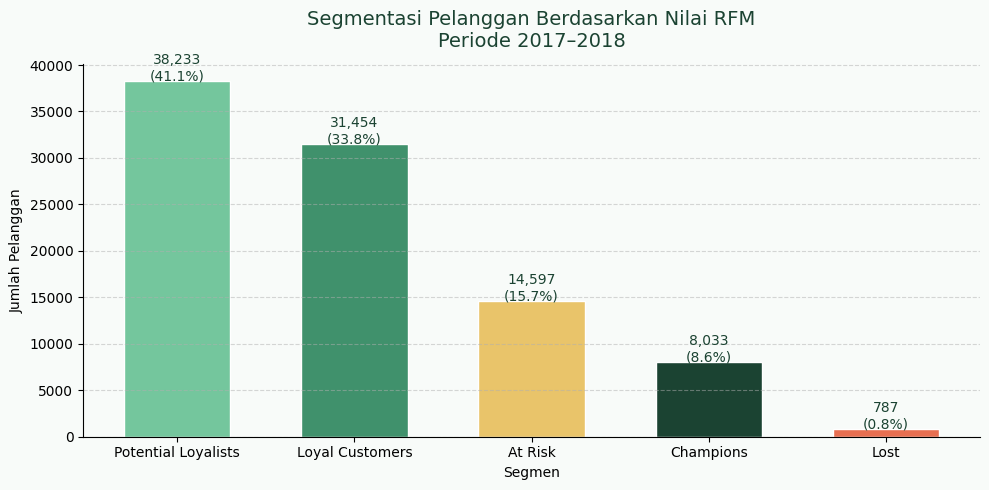

In [57]:
seg_counts = rfm_df['segment'].value_counts().reset_index()
seg_counts.columns = ['segment', 'count']
segment_order = ['Potential Loyalists', 'Loyal Customers', 'At Risk', 'Champions', 'Lost']
seg_counts['segment'] = pd.Categorical(seg_counts['segment'], categories=segment_order, ordered=True)
seg_counts = seg_counts.sort_values('segment')

seg_colors = {
    'Champions': '#1B4332',
    'Loyal Customers': '#40916C',
    'Potential Loyalists': '#74C69D',
    'At Risk': '#E9C46A',
    'Lost': '#E76F51'
}

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#F8FBF9')
ax.set_facecolor('#F8FBF9')

bars = ax.bar(
    seg_counts['segment'],
    seg_counts['count'],
    color=[seg_colors.get(s, '#2D6A4F') for s in seg_counts['segment']],
    edgecolor='white',
    width=0.6
)

for bar in bars:
    h = bar.get_height()
    pct = h / seg_counts['count'].sum() * 100
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 100,
        f'{int(h):,}\n({pct:.1f}%)',
        ha='center',
        fontsize=10,
        color='#1B4332'
    )

ax.set_title(
    'Segmentasi Pelanggan Berdasarkan Nilai RFM\nPeriode 2017–2018',
    fontsize=14,
    color='#1B4332',
    pad=12
)
ax.set_xlabel('Segmen')
ax.set_ylabel('Jumlah Pelanggan')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('rfm_segmentasi_2017_2018.png', dpi=150, bbox_inches='tight')
plt.show()

###GEOSPATIAL ANALYSIS


Analisis geospatial digunakan untuk melihat sebaran pelanggan secara geografis berdasarkan koordinat latitude dan longitude. Dengan visualisasi peta, kita bisa dengan mudah melihat di wilayah mana konsentrasi pelanggan paling tinggi.

In [58]:
geo_customers = filtered_df[['customer_unique_id', 'geolocation_lat', 'geolocation_lng']].dropna().drop_duplicates(subset='customer_unique_id')

print('jumlah pelanggan dengan koordinat:', len(geo_customers))
geo_customers.head()

jumlah pelanggan dengan koordinat: 92850


,customer_unique_id,geolocation_lat,geolocation_lng
0,7c396fd4830fd04220f754e42b4e5bff,-23.574809,-46.587471
1,af07308b275d755c9edb36a90c618231,-12.169860,-44.988369
2,3a653a41f6f9fc3d2a113cf8398680e8,-16.746337,-48.514624
3,7c142cf63193a1473d2e66489a9ae977,-5.767733,-35.275467
4,72632f0f9dd73dfee390c9b22eb56dd6,-23.675037,-46.524784


In [59]:
m = folium.Map(location=[-14.2350, -51.9253], zoom_start=4, tiles='CartoDB positron')

heat_data = geo_customers[['geolocation_lat', 'geolocation_lng']].values.tolist()

HeatMap(
    heat_data,
    min_opacity=0.3,
    radius=8,
    blur=10,
    gradient={0.4: '#74C69D', 0.65: '#40916C', 1.0: '#1B4332'}
).add_to(m)

m.save('geospatial_customers_2017_2018.html')
m

###CLUSTERING MANUAL ATAU SEGMENTASI PELANGGAN RFM


Pengelompokan pelanggan berdasarkan skor RFM tanpa machine learning. Teknik ini menggunakan binning manual untuk menentukan segmen pelanggan berdasarkan aturan bisnis yang sudah ditetapkan sebelumnya.

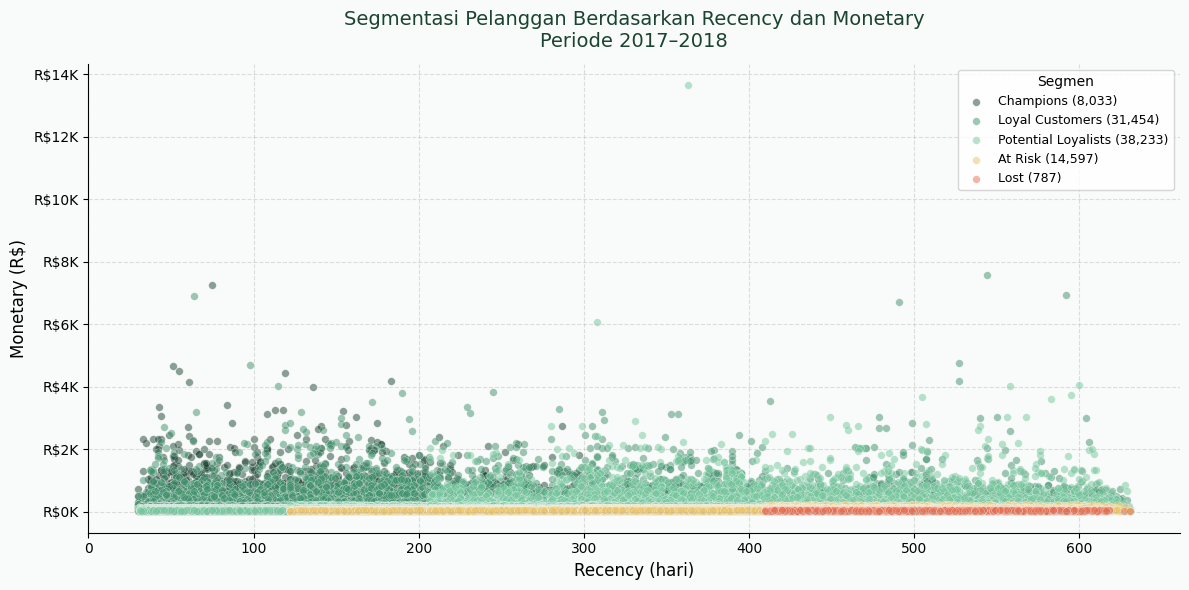

In [60]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#F8FBF9')
ax.set_facecolor('#F8FBF9')

seg_palette = {
    'Champions': '#1B4332',
    'Loyal Customers': '#40916C',
    'Potential Loyalists': '#74C69D',
    'At Risk': '#E9C46A',
    'Lost': '#E76F51'
}

for segment, color in seg_palette.items():
    subset = rfm_df[rfm_df['segment'] == segment]
    ax.scatter(
        subset['recency'],
        subset['monetary'],
        c=color,
        label=f'{segment} ({len(subset):,})',
        alpha=0.5,
        s=30,
        edgecolors='white',
        linewidth=0.3
    )

ax.set_xlabel('Recency (hari)', fontsize=12)
ax.set_ylabel('Monetary (R$)', fontsize=12)
ax.set_title(
    'Segmentasi Pelanggan Berdasarkan Recency dan Monetary\nPeriode 2017–2018',
    fontsize=14,
    color='#1B4332',
    pad=12
)
ax.legend(title='Segmen', fontsize=9, loc='upper right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e3:.0f}K'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('rfm_segmentasi_recency_monetary_2017_2018.png', dpi=150, bbox_inches='tight')
plt.show()

In [61]:
all_df.to_csv('main_data.csv', index=False)
print('main_data.csv berhasil disimpan')

main_data.csv berhasil disimpan


## Conclusion

- Conclution pertanyaan 1

Berdasarkan analisis tren penjualan bulanan pada periode 2017–2018, terlihat bahwa jumlah pesanan dan total revenue menunjukkan pola peningkatan secara bertahap dengan fluktuasi di beberapa bulan. Puncak transaksi terjadi pada akhir tahun, khususnya sekitar November–Desember, yang mengindikasikan adanya pengaruh faktor musiman (seasonality) seperti promosi besar atau event tertentu. Hal ini menunjukkan bahwa performa bisnis dipengaruhi oleh periode waktu tertentu sehingga strategi penjualan perlu difokuskan pada periode high season untuk memaksimalkan revenue.
- Conclution pertanyaan 2

Berdasarkan analisis kategori produk selama periode 2017–2018, kategori bed_bath_table memiliki jumlah pesanan tertinggi, yang menunjukkan tingginya permintaan terhadap produk kebutuhan rumah tangga. Namun, kategori seperti health_beauty dan watches_gifts menghasilkan total revenue yang lebih tinggi, yang mengindikasikan bahwa kategori tersebut memiliki nilai transaksi rata-rata yang lebih besar. Hal ini menunjukkan adanya perbedaan antara kategori dengan volume transaksi tinggi (high-volume) dan kategori dengan nilai transaksi tinggi (high-value), sehingga strategi pemasaran dan pricing perlu disesuaikan untuk masing-masing kategori.
- Conclution pertanyaan 3

Berdasarkan analisis distribusi pelanggan pada periode 2017–2018, pelanggan terkonsentrasi secara signifikan di wilayah Sao Paulo (SP), baik dari sisi state maupun city. Kota Sao Paulo menjadi pusat aktivitas dengan jumlah pelanggan tertinggi, diikuti oleh kota besar lainnya seperti Rio de Janeiro dan Belo Horizonte. Hal ini menunjukkan bahwa aktivitas e-commerce masih terpusat di wilayah urban dengan tingkat ekonomi tinggi, sehingga peluang ekspansi masih terbuka di wilayah lain yang belum optimal.
- Conclution pertanyaan 4

Berdasarkan analisis segmentasi pelanggan menggunakan metode RFM pada periode 2017–2018, mayoritas pelanggan berada pada segmen Potential Loyalists dan Loyal Customers, yang menunjukkan bahwa sebagian besar pelanggan cukup aktif dan memiliki potensi untuk dipertahankan. Pelanggan dengan nilai RFM tertinggi didominasi oleh segmen Champions, yang memiliki frekuensi transaksi tinggi, nilai belanja besar, dan recency yang rendah (baru saja melakukan transaksi). Sementara itu, segmen At Risk dan Lost menunjukkan adanya pelanggan yang mulai tidak aktif dan berpotensi churn, sehingga diperlukan strategi re-engagement untuk mengurangi kehilangan pelanggan.

Secara keseluruhan, analisis ini menunjukkan adanya pola seasonality, perbedaan karakteristik kategori produk, konsentrasi geografis pelanggan, serta segmentasi nilai pelanggan yang jelas. Temuan ini dapat digunakan sebagai dasar dalam pengambilan keputusan berbasis data untuk meningkatkan performa bisnis.